<a href="https://colab.research.google.com/github/bingjunw/ust-deep-learning-2026/blob/main/Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6

**Load Libraries and Set Up Data**

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input
from tensorflow.keras.datasets import fashion_mnist
from sklearn.manifold import TSNE

In [2]:
# Load Fashion-MNIST: 60,000 training samples, 10,000 test samples
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# Normalization: Scale pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# Flatten images from 28x28 to 784-dimensional vectors
x_train_flat = x_train.reshape((-1, 784))
x_test_flat = x_test.reshape((-1, 784))
print(f"Training data shape: {x_train_flat.shape}")
print(f"Test data shape: {x_test_flat.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 784)
Test data shape: (10000, 784)


**Define the Model Architectures**

In [3]:
# Input layer
input_layer = Input(shape=(784,), name='input_layer')

# Encoder Layers
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
# Bottleneck
bottleneck = Dense(32, activation='relu', name='bottleneck_layer')(encoded)

# Decoder Layers
decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
# Output layer
output_layer = Dense(784, activation='sigmoid', name='output_layer')(decoded)

# Construct Autoencoder Model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Construct separate Encoder Model for visualization
encoder_model = Model(inputs=input_layer, outputs=bottleneck)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_layer (Dense)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

**Training loop and visualization**

In [4]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',
                           patience=3,
                           restore_best_weights=True)

autoencoder.fit(
    x_train_flat, x_train_flat,
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0859 - val_loss: 0.0281
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0258 - val_loss: 0.0223
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0215 - val_loss: 0.0200
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0195 - val_loss: 0.0185
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0182 - val_loss: 0.0178
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0173 - val_loss: 0.0171
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0167 - val_loss: 0.0166
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0163 - val_loss: 0.0161
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0158 - val_loss: 0.0155
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0154 - val_loss: 0.0151
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0150 - val_loss: 0.0148
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/ste

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Running t-SNE reduction...


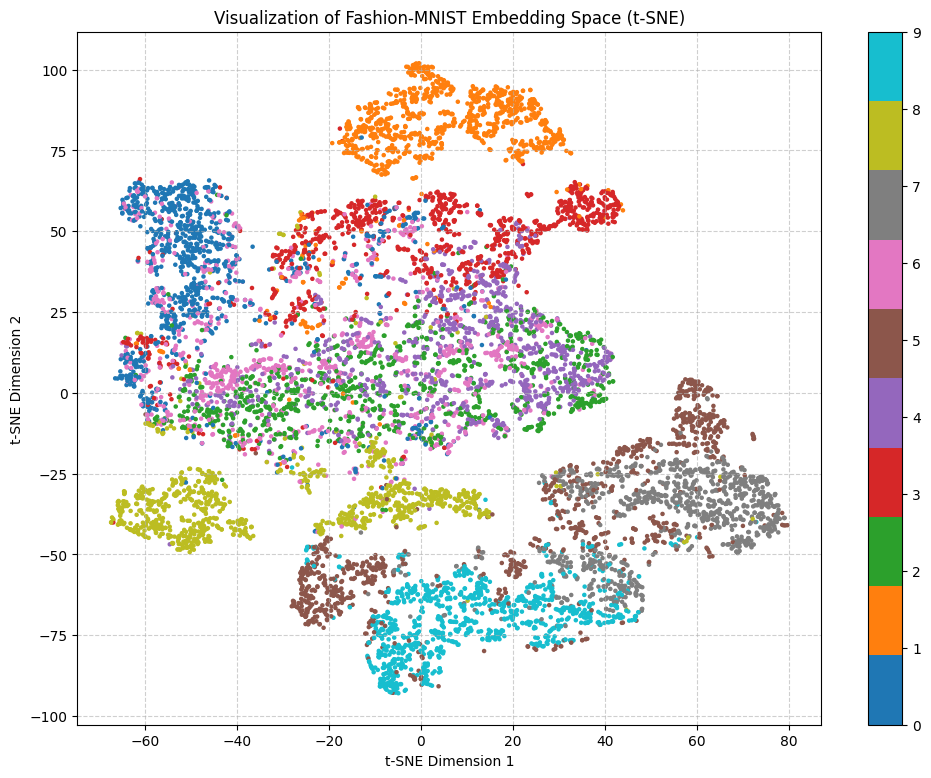

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


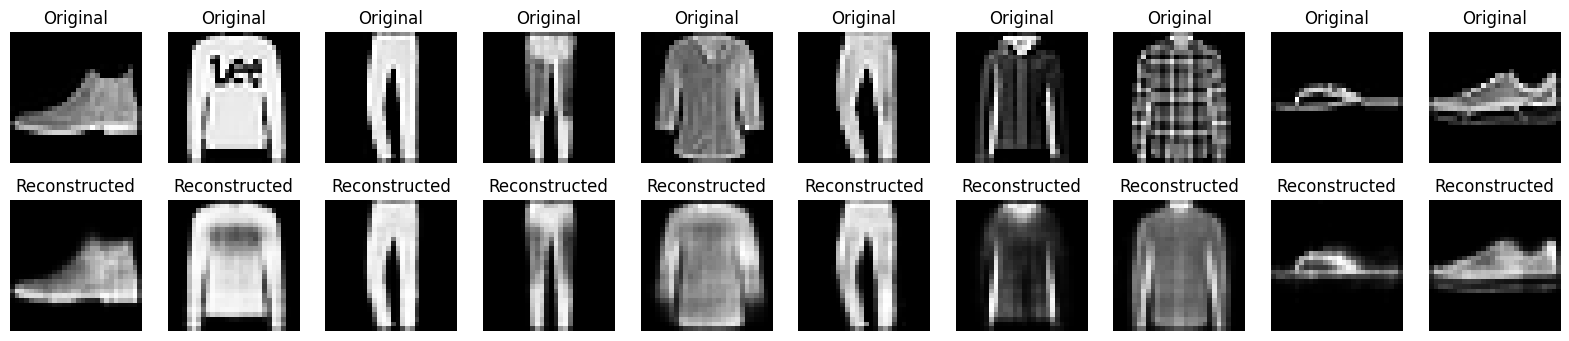

In [5]:
# Embedding Space Visualization
# Extract the encoder part to get the hidden representation (bottleneck)
encoder_model = Model(inputs=autoencoder.input,
                      outputs=autoencoder.get_layer('bottleneck_layer').output)

# Get latent representations for the test set
embeddings = encoder_model.predict(x_test_flat)

# Dimension reduction using t-SNE for 2D visualization
print("Running t-SNE reduction...")
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

# Plotting the Embedding Space
plt.figure(figsize=(12, 9))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=y_test, cmap='tab10', s=5)
plt.colorbar(scatter)
plt.title("Visualization of Fashion-MNIST Embedding Space (t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Reconstruction Result Visualization
reconstructed_imgs = autoencoder.predict(x_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display Original Images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title("Original")
    ax.axis('off')

    # Display Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    ax.axis('off')
plt.show()